<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/002_Missing_Data_Recovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# /02<br>Missing Data Recovery

**What we can do**
- delete object
- delete column
- replace value

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
rng = np.random.default_rng()

## Prepare Data

In [3]:
import kagglehub

path = kagglehub.dataset_download("akshatsharma2/all-in-one-dataset-for-preprocessing-practice")
print("Path to dataset files:", path)

100%|██████████| 7.07k/7.07k [00:00<00:00, 10.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/akshatsharma2/all-in-one-dataset-for-preprocessing-practice/versions/1


In [4]:
df = pd.read_csv(f'{path}/my_data (1).csv')

features = {
    'nominal'  : ['name', 'city', 'gender'],
    'ordinal'  : ['profession'],
    'numerical': ['age', 'cgpa'],
    'label'    : ['placed']
}

df_transform = df.copy()

scaler = StandardScaler()
df_transform[features['numerical']] = scaler.fit_transform(df_transform[features['numerical']])

oe_nom = OrdinalEncoder()
df_transform[features['nominal']] = oe_nom.fit_transform(df_transform[features['nominal']])

prof = ['bachelor', 'masters', 'phd']
oe_ord = OrdinalEncoder(
    categories=[prof],
    handle_unknown='use_encoded_value',
    unknown_value=np.nan
)
df_transform[features['ordinal']] = oe_ord.fit_transform(df_transform[features['ordinal']])

df_transform.head()

,name,city,gender,profession,age,cgpa,placed
0,4.0,NaN,0.0,2.0,-0.047035,-1.116251,1
1,4.0,0.0,NaN,0.0,2.360866,0.629320,0
2,3.0,NaN,0.0,1.0,-1.141535,-1.370396,0
3,5.0,NaN,1.0,0.0,-0.375385,0.642696,1
4,5.0,NaN,1.0,0.0,-1.032085,0.769768,1


In [5]:
# Scalling all data

df_scalling = df_transform.copy()

em_scaler = StandardScaler()
df_scalling = pd.DataFrame(
    columns=df_scalling.columns,
    data=em_scaler.fit_transform(df_scalling)
)

FULL_BASE = df_scalling.dropna() # all features are present

df_scalling.head()

,name,city,gender,profession,age,cgpa,placed
0,0.097830,NaN,-1.802183,1.953115,-0.047035,-1.116251,1.001820
1,0.097830,-1.577261,NaN,-0.799477,2.360866,0.629320,-0.998183
2,-0.479423,NaN,-1.802183,0.576819,-1.141535,-1.370396,-0.998183
3,0.675083,NaN,0.554883,-0.799477,-0.375385,0.642696,1.001820
4,0.675083,NaN,0.554883,-0.799477,-1.032085,0.769768,1.001820


## Recovery Numerical Features using Euclidean Metrics

**Recovery Formula:**
$$
P(A) = \frac{1}{\sum_{i=1}^{n}\frac{1}{\rho(A, A_i)}}\sum_{i=1}^{n}\frac{A_i}{\rho(A, A_i)}
$$

, where $\rho$ is the metric

<br>

**Euclidean Metrics:**
$$
\rho(P, Q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}
$$


In [6]:
em_distance = lambda p, q: ((p - q)**2).sum(axis=1) # Euclidean metric
mm_distance = lambda p, q: np.abs(p - q).sum(axis=1) # Manhattan Geometry

metrics = {
    'euclidean': em_distance,
    'manhattan': mm_distance,
}

def recovery(row, col_for_recovery, metric='euclidean'):
    distances = metrics[metric](
        FULL_BASE.drop([col_for_recovery] + row['nan'], axis=1),
        row.drop('nan')
    )
    distances += 1e-10 # division-by-zero protection

    scale_factor = df.shape[1] / (df.shape[1] - len(row['nan']))
    actual_distance = 1 / (1 / distances).sum() * (FULL_BASE[col_for_recovery] / distances).sum()

    return actual_distance * np.sqrt(scale_factor)


In [7]:
def get_recovery_df(column):
    recovery = df_scalling[df_scalling[column].isnull()].copy()
    recovery.drop(column, axis=1, inplace=True)
    recovery['nan'] = recovery.apply(lambda r: r[r.isna()].index.to_list(), axis=1)

    return recovery


### Recovering 'Age' Values

In [8]:
AGE_recovery = get_recovery_df('age')
AGE_recovery['age'] = AGE_recovery.apply(recovery, col_for_recovery='age', axis=1)

AGE_recovery.head()

,name,city,gender,profession,cgpa,placed,nan,age
9,-1.633929,NaN,-1.802183,0.576819,0.495559,1.001820,[city],-0.039515
19,1.829589,1.011774,0.554883,-0.799477,0.475495,-0.998183,[],0.160776
34,0.675083,-1.577261,NaN,NaN,-0.159866,-0.998183,"[gender, profession]",-0.487309
38,0.675083,-0.714249,0.554883,-0.799477,0.174535,-0.998183,[],0.565862
70,0.097830,-0.714249,0.554883,-0.799477,-2.079325,-0.998183,[],0.012386


In [9]:
em_custom = df_scalling.copy()

em_custom.loc[em_custom['age'].isna(), 'age'] = AGE_recovery['age']

### Recovering 'CGPA' Values

In [10]:
CGPA_recovery = get_recovery_df('cgpa')
CGPA_recovery['cgpa'] = CGPA_recovery.apply(recovery, col_for_recovery='cgpa', axis=1)

CGPA_recovery.head()

,name,city,gender,profession,age,placed,nan,cgpa
11,0.097830,0.148762,0.554883,-0.799477,-0.047035,1.001820,[],-0.229505
14,0.675083,1.011774,0.554883,-0.799477,-0.156485,-0.998183,[],-0.233434
32,-1.056676,NaN,0.554883,0.576819,1.923066,-0.998183,[city],-0.846280
37,0.675083,1.011774,-1.802183,NaN,-0.813185,1.001820,[profession],-0.487567
39,0.675083,-0.714249,0.554883,1.953115,-0.375385,-0.998183,[],-0.879102


In [11]:
em_custom.loc[em_custom['cgpa'].isna(), 'cgpa'] = CGPA_recovery['cgpa']

### Recovering 'Age' and 'CGPA' w/ KNNImputer

In [12]:
imputer = KNNImputer(n_neighbors=5)

recovered = pd.DataFrame(
    data=imputer.fit_transform(df_scalling),
    columns=df_scalling.columns,
)

recovered.head()

,name,city,gender,profession,age,cgpa,placed
0,0.097830,0.148762,-1.802183,1.953115,-0.047035,-1.116251,1.001820
1,0.097830,-1.577261,0.083470,-0.799477,2.360866,0.629320,-0.998183
2,-0.479423,0.321365,-1.802183,0.576819,-1.141535,-1.370396,-0.998183
3,0.675083,-0.196442,0.554883,-0.799477,-0.375385,0.642696,1.001820
4,0.675083,-0.196442,0.554883,-0.799477,-1.032085,0.769768,1.001820


In [13]:
em_knnimputer = df_scalling.copy()

em_knnimputer.loc[em_knnimputer['age'].isna(), 'age'] = recovered.loc[
    df_scalling[df_scalling['age'].isna()]['age'].index, 'age'
]
em_knnimputer.loc[em_knnimputer['cgpa'].isna(), 'cgpa'] = recovered.loc[
    df_scalling[df_scalling['cgpa'].isna()]['cgpa'].index, 'cgpa'
]

em_knnimputer.head()

,name,city,gender,profession,age,cgpa,placed
0,0.097830,NaN,-1.802183,1.953115,-0.047035,-1.116251,1.001820
1,0.097830,-1.577261,NaN,-0.799477,2.360866,0.629320,-0.998183
2,-0.479423,NaN,-1.802183,0.576819,-1.141535,-1.370396,-0.998183
3,0.675083,NaN,0.554883,-0.799477,-0.375385,0.642696,1.001820
4,0.675083,NaN,0.554883,-0.799477,-1.032085,0.769768,1.001820


### Comparison

In [14]:
NaN_age_idxs = df_scalling[df_scalling['age'].isna()].index
NaN_cgpa_idxs = df_scalling[df_scalling['cgpa'].isna()].index

original_custom = pd.DataFrame(
    data=em_scaler.inverse_transform(em_custom),
    columns=em_custom.columns
)

original_custom.loc[:, ['age', 'cgpa']] = scaler.inverse_transform(original_custom[['age', 'cgpa']])

original_custom.head()

,name,city,gender,profession,age,cgpa,placed
0,4.0,NaN,0.0,2.0,28.0,5.94,1.0
1,4.0,-2.220446e-16,NaN,0.0,50.0,8.55,0.0
2,3.0,NaN,0.0,1.0,18.0,5.56,0.0
3,5.0,NaN,1.0,0.0,25.0,8.57,1.0
4,5.0,NaN,1.0,0.0,19.0,8.76,1.0


In [15]:
original_knnimputer = pd.DataFrame(
    data=em_scaler.inverse_transform(em_knnimputer),
    columns=em_knnimputer.columns
)

original_knnimputer.loc[:, ['age', 'cgpa']] = scaler.inverse_transform(em_knnimputer[['age', 'cgpa']])

original_knnimputer.head()

,name,city,gender,profession,age,cgpa,placed
0,4.0,NaN,0.0,2.0,28.0,5.94,1.0
1,4.0,-2.220446e-16,NaN,0.0,50.0,8.55,0.0
2,3.0,NaN,0.0,1.0,18.0,5.56,0.0
3,5.0,NaN,1.0,0.0,25.0,8.57,1.0
4,5.0,NaN,1.0,0.0,19.0,8.76,1.0


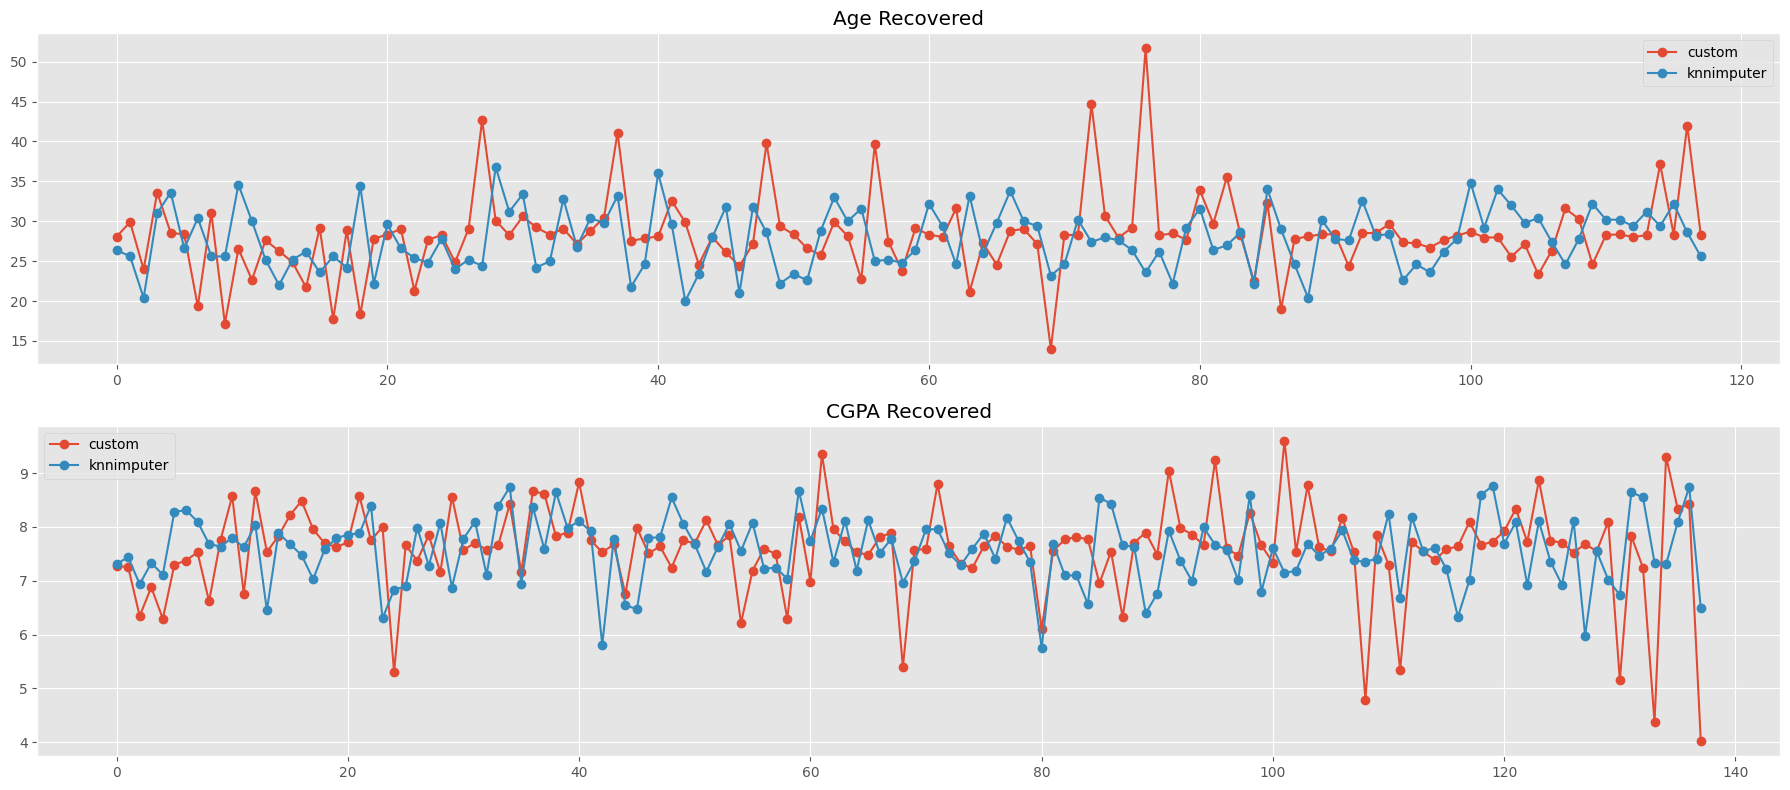

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(18, 8))

axs[0].plot(np.arange(len(NaN_age_idxs)), original_custom.loc[NaN_age_idxs]['age'], marker='o', label='custom')
axs[0].plot(np.arange(len(NaN_age_idxs)), original_knnimputer.loc[NaN_age_idxs]['age'], marker='o', label='knnimputer')
axs[0].set_title('Age Recovered')
axs[0].legend()

axs[1].plot(np.arange(len(NaN_cgpa_idxs)), original_custom.loc[NaN_cgpa_idxs]['cgpa'], marker='o', label='custom')
axs[1].plot(np.arange(len(NaN_cgpa_idxs)), original_knnimputer.loc[NaN_cgpa_idxs]['cgpa'], marker='o', label='knnimputer')
axs[1].set_title('CGPA Recovered')
axs[1].legend()

plt.tight_layout()

Custom apply()-based imputation uses a fixed per-feature formula. KNNImputer averages over k nearest neighbors, which smooths the data and reduces outliers, making it more robust for ML tasks.

## Recovering Nominal and Ordinal Feutures Using Manhattan Geometry

$$
\rho(P, Q) = \sum_{i=1}^{n}|p_i - q_i|
$$

In [17]:
mm = df_transform.drop(['age', 'cgpa'], axis=1)

FULL_BASE = mm.dropna() # all features are present

def get_recovery_df(column):
    recovery = mm[mm[column].isnull()].copy()
    recovery.drop(column, axis=1, inplace=True)
    recovery['nan'] = recovery.apply(lambda r: r[r.isna()].index.to_list(), axis=1)

    return recovery


### Recovering 'Name' Values

In [18]:
NAME_recovery = get_recovery_df('name')

NAME_recovery['name'] = NAME_recovery.apply(
    recovery, col_for_recovery='name', metric='manhattan',
    axis=1
)
NAME_recovery['name'] = NAME_recovery['name'].map(np.round)

NAME_recovery.head()

,city,gender,profession,placed,nan,name
6,3.0,1.0,NaN,0,[profession],4.0
7,3.0,1.0,0.0,0,[],4.0
18,2.0,0.0,0.0,1,[],5.0
28,3.0,1.0,2.0,0,[],4.0
36,3.0,0.0,1.0,0,[],5.0


### Recovering 'City' Values

In [19]:
CITY_recovery = get_recovery_df('city')

CITY_recovery['city'] = CITY_recovery.apply(
    recovery, col_for_recovery='city', metric='manhattan',
    axis=1
)
CITY_recovery['city'] = CITY_recovery['city'].map(np.round)

CITY_recovery.head()

,name,gender,profession,placed,nan,city
0,4.0,0.0,2.0,1,[],2.0
2,3.0,0.0,1.0,0,[],2.0
3,5.0,1.0,0.0,1,[],2.0
4,5.0,1.0,0.0,1,[],2.0
9,1.0,0.0,1.0,1,[],3.0


### Recovering 'Gender' Values

In [20]:
GENDER_recovery = get_recovery_df('gender')

GENDER_recovery['gender'] = GENDER_recovery.apply(
    recovery, col_for_recovery='gender', metric='manhattan',
    axis=1
)
GENDER_recovery['gender'] = GENDER_recovery['gender'].map(np.round)

GENDER_recovery.head()

,name,city,profession,placed,nan,gender
1,4.0,0.0,0.0,0,[],1.0
17,5.0,0.0,0.0,0,[],1.0
29,0.0,1.0,0.0,1,[],1.0
34,5.0,0.0,NaN,0,[profession],1.0
43,NaN,1.0,0.0,1,[name],1.0


### Recovering 'Profession' Values

In [21]:
PROF_recovery = get_recovery_df('profession')

PROF_recovery['profession'] = PROF_recovery.apply(
    recovery, col_for_recovery='profession', metric='manhattan',
    axis=1
)
PROF_recovery['profession'] = PROF_recovery['profession'].map(np.round)

PROF_recovery.head()

,name,city,gender,placed,nan,profession
6,NaN,3.0,1.0,0,[name],1.0
8,4.0,0.0,0.0,0,[],0.0
21,3.0,3.0,1.0,0,[],0.0
31,4.0,NaN,1.0,1,[city],1.0
33,5.0,1.0,1.0,1,[],0.0


## Data Normalization

In [ ]:
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
print("Path to dataset files:", path)

In [ ]:
df = pd.read_csv(f'{path}/Life Expectancy Data.csv')
df.drop('Status', inplace=True, axis=1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

### Min-max

All values in the interval [0, 1]

$$
p'_i = \frac{p_i - min\{p_i\}}{max\{p_i\} - min\{p_i\}}
$$

Skew:
Original: -0.63
Normalized: -0.63


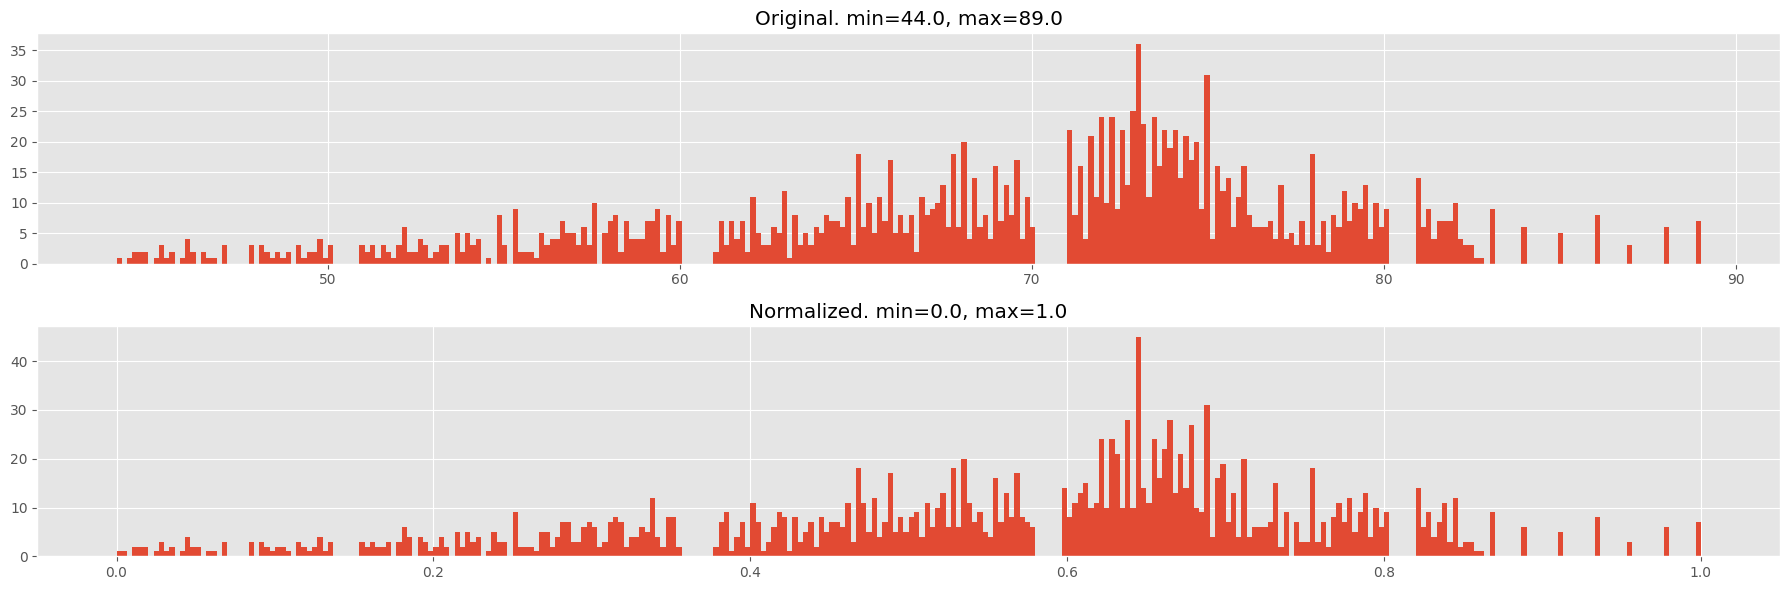

In [ ]:
life_exp_norm = (df['Life expectancy '] - df['Life expectancy '].min()) / \
(df['Life expectancy '].max() - df['Life expectancy '].min())

print(f'Skew:\nOriginal: {np.round(stats.skew(df['Life expectancy ']), 2)}')
print(f'Normalized: {np.round(stats.skew(life_exp_norm), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['Life expectancy '], bins=300)
axs[0].set_title(f'Original. min={df['Life expectancy '].min()}, max={df['Life expectancy '].max()}')

axs[1].hist(life_exp_norm, bins=300)
axs[1].set_title(f'Normalized. min={life_exp_norm.min()}, max={life_exp_norm.max()}')

plt.tight_layout()

### Z-score
The mean will be 0, standard deviation 1
$$
p_i = \frac{p_i - \mu}{\sigma}
$$

Skew:
Original: -2.36
Normalized: -2.36


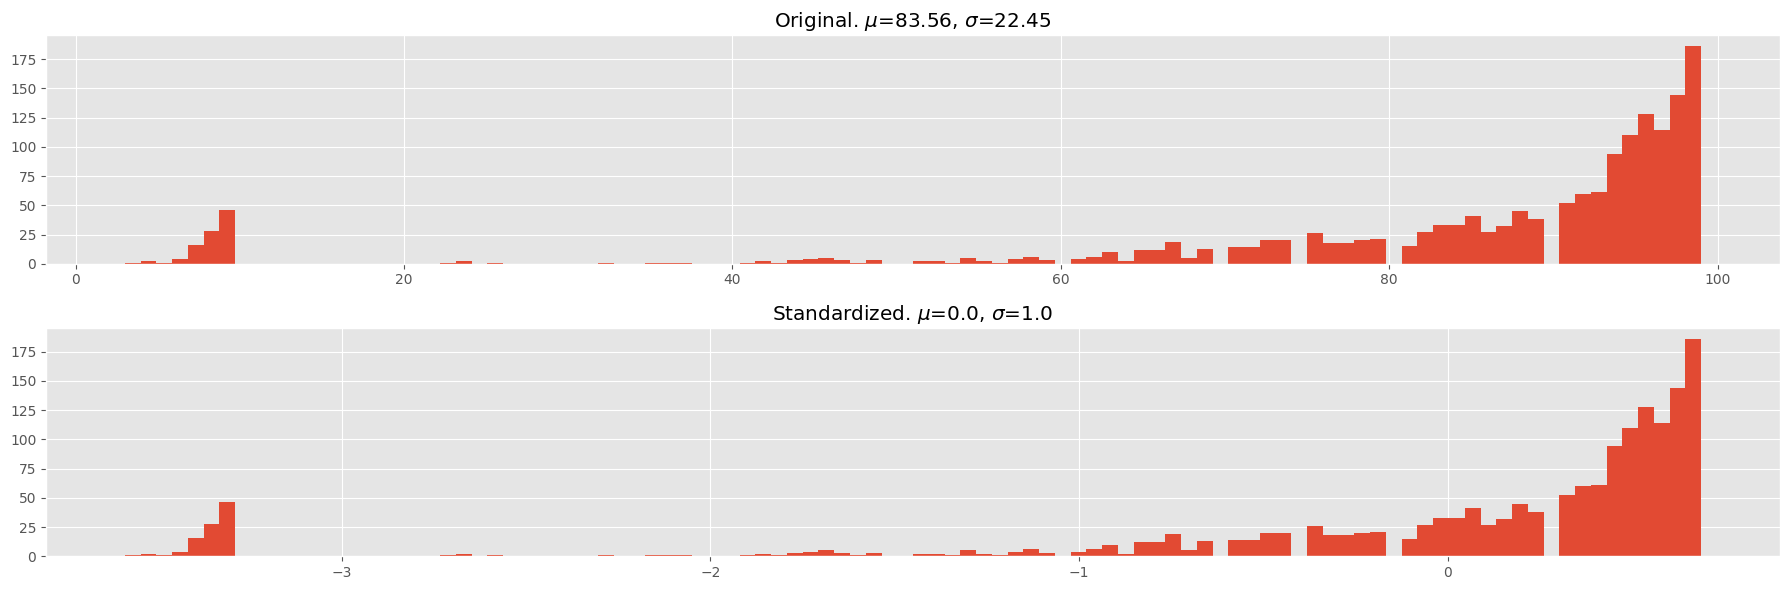

In [ ]:
polio_z = (df['Polio'] - df['Polio'].mean()) / df['Polio'].std()

print(f'Skew:\nOriginal: {np.round(stats.skew(df['Polio']), 2)}')
print(f'Normalized: {np.round(stats.skew(polio_z), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['Polio'], bins=100)
axs[0].set_title(fr'Original. $\mu$={np.round(df['Polio'].mean(), 2)}, $\sigma$={np.round(df['Polio'].std(), 2)}')

axs[1].hist(polio_z, bins=100)
axs[1].set_title(fr'Standardized. $\mu$={np.round(polio_z.mean(), 2)}, $\sigma$={np.round(polio_z.std(), 2)}')

plt.tight_layout()

### Logarithm

Used for highly skewed data

Skew:
Original: 4.51
Normalized: -0.23


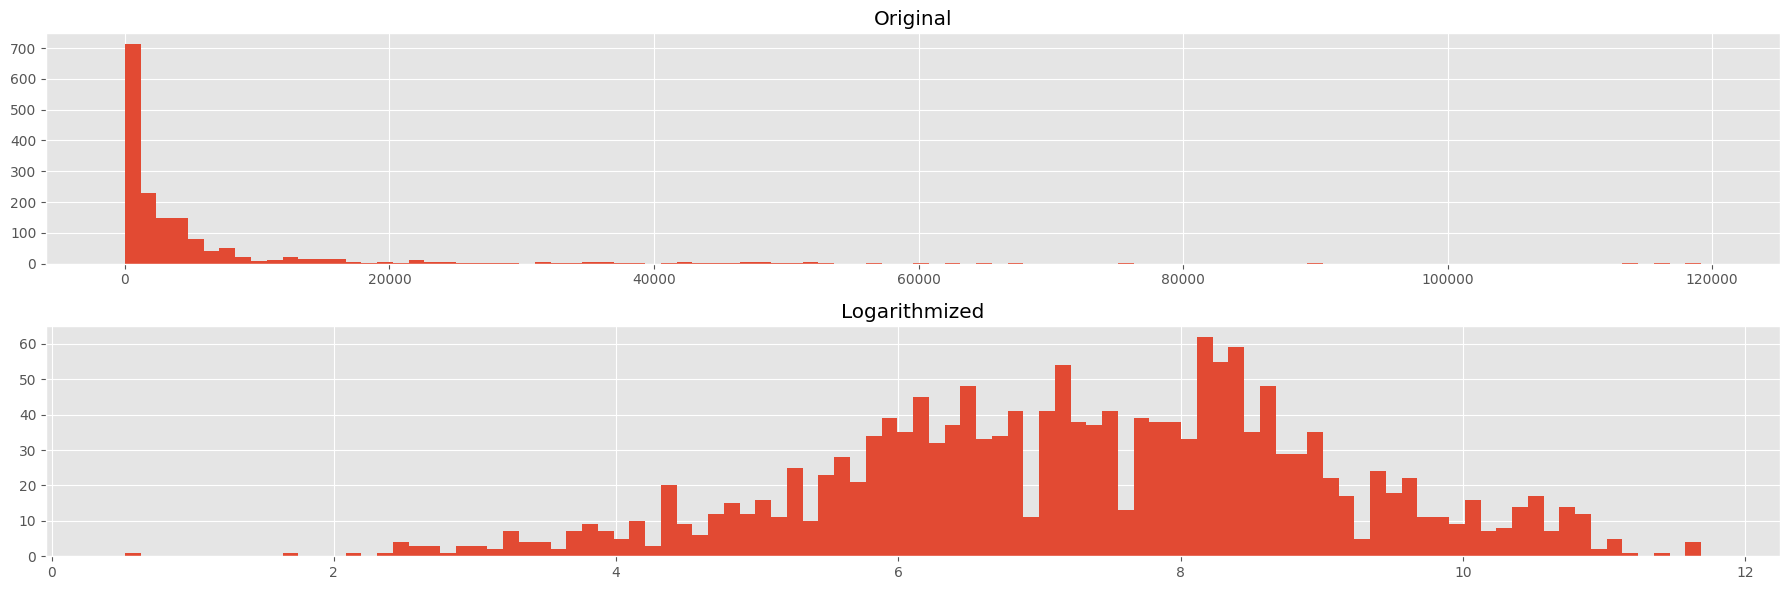

In [ ]:
gdp_log = np.log(df['GDP'])

print(f'Skew:\nOriginal: {np.round(stats.skew(df['GDP']), 2)}')
print(f'Normalized: {np.round(stats.skew(gdp_log), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['GDP'], bins=100)
axs[0].set_title('Original')

axs[1].hist(gdp_log, bins=100)
axs[1].set_title('Logarithmized')

plt.tight_layout()

### Testing the effect of taking logarithms of features on the accuracy of linear regression

In [ ]:
exp = df.drop(['Country', 'Year'], axis=1)
exp = exp.astype('float64')
exp_log = exp.copy()

skew = pd.DataFrame(
    data=stats.skew(exp),
    index=exp.columns,
    columns=['Skew']
)
skew_cols = skew[((skew['Skew']>2) | (skew['Skew']<-2))].index

scaler = StandardScaler()
exp = pd.DataFrame(
    data=scaler.fit_transform(exp),
    columns=exp.columns
)

exp_log.loc[:, skew_cols] = np.log1p(exp_log[skew_cols])
scaler_log = StandardScaler()
exp_log = pd.DataFrame(
    data=scaler_log.fit_transform(exp_log),
    columns=exp_log.columns
)


In [ ]:
X = exp.drop('Life expectancy ', axis=1)
y = exp['Life expectancy ']

X_log = exp_log.drop('Life expectancy ', axis=1)
y_log = exp_log['Life expectancy ']

def lin_reg_score(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

    reg = LinearRegression().fit(X_train, y_train)
    return reg.score(X_test, y_test)

print(f'W/O log: {lin_reg_score(X, y)}')
print(f'W/ log: {lin_reg_score(X_log, y_log)}')

W/O log: 0.8343045821598958
W/ log: 0.8572926731825358


## Recovering data w/ correlation coefficient

**Correlation Coefficient:**

$$
r(P, Q) = \frac{\sum^n_{i=1}p_iq_i - n\overline{p}\overline{q}}{(n-1)s_ps_q}
$$


**Recovery Formula:**

$$
P(A) = \overline{p} + \frac{\sum^n_{i=1}r(P, p_i)(p_i(A) - \overline{p_i})}{\sum_{i=1}^m|r(P, p_i)|}
$$

In [ ]:
r = lambda p, q, n: ((p*q).sum() - n*p.mean()*q.mean()) / ((n - 1)*p.std()*q.std())

### Recovering by one feature

In [ ]:
data = pd.DataFrame({
    'life expectancy': df['Life expectancy '], # target
    'schooling': df['Schooling']
})

nans_ids = rng.integers(low=0, high=data.shape[0], size=50)
nan_data = data.copy()
nan_data.loc[nans_ids, 'life expectancy'] = np.nan

complete_data = nan_data.dropna()

In [ ]:
r_coeff = r(complete_data['life expectancy'], complete_data['schooling'], complete_data.shape[0])
r_coeff

np.float64(0.7282602005143505)

In [ ]:
P_mean, p_mean = complete_data.mean()
p_A = data.loc[nans_ids]['schooling']

recovered_data_1f = np.round(P_mean + np.sign(r_coeff) * (p_A - p_mean), 1)

### Recovering by several features

In [ ]:
df.drop(['Country', 'Year'], axis=1).corr()['Life expectancy '].sort_values()

,Life expectancy
Adult Mortality,-0.702523
HIV/AIDS,-0.592236
thinness 1-19 years,-0.457838
thinness 5-9 years,-0.457508
under-five deaths,-0.192265
infant deaths,-0.169074
Measles,-0.068881
Population,-0.022305
Total expenditure,0.174718
Hepatitis B,0.199935


In [ ]:
features = [
    'Schooling',
    'Income composition of resources',
    'Adult Mortality',
    ' HIV/AIDS'
]

data = df[features + ['Life expectancy ']].copy()

nan_data = data.copy()
nan_data.loc[nans_ids, 'Life expectancy '] = np.nan

complete_data = nan_data.dropna()

In [ ]:
p = complete_data.drop('Life expectancy ', axis=1)
q = complete_data['Life expectancy ']
n = complete_data.shape[0]

r_coeffs = ((p.T * q).T.sum() - n*p.mean()*q.mean()) / ((n - 1)*p.std()*q.std())
r_coeffs

,0
Schooling,0.728260
Income composition of resources,0.720250
Adult Mortality,-0.703087
HIV/AIDS,-0.592075


In [ ]:
p_A = data.loc[nans_ids].drop('Life expectancy ', axis=1)

recovered_data_4f = q.mean() + (r_coeffs*(p_A - p.mean())).sum(axis=1) / np.abs(r_coeffs).sum()
recovered_data_4f = recovered_data_4f.map(lambda i: np.round(i, 2))

### Comparing 1-feature and 4-features rcovering

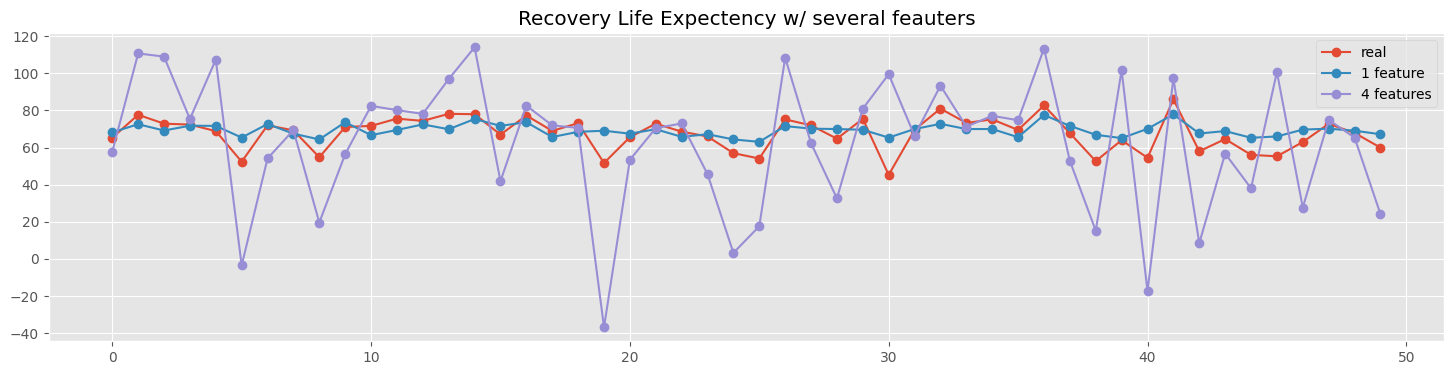

In [ ]:
plt.figure(figsize=(18, 4))

plt.plot(data.loc[nans_ids]['Life expectancy '].to_list(), marker='o', label='real')
plt.plot(recovered_data_1f.to_list(), marker='o', label='1 feature')
plt.plot(recovered_data_4f.to_list(), marker='o', label='4 features')
plt.title('Recovery Life Expectency w/ several feauters')
plt.legend()


In [ ]:
r2 = lambda pred, real: np.round(1 - ((pred - real)**2).sum() / ((pred - real.mean())**2).sum(), 2)

r2(recovered_data_1f, data.loc[nans_ids]['Life expectancy ']), r2(recovered_data_4f, data.loc[nans_ids]['Life expectancy '])

(np.float64(-2.85), np.float64(0.28))